# Spatial Rainfall Correlations

This notebook plots spatial rainfall correlations with Niño 3.4 for P1 (1981–2000), P2 (2001–2025), and their difference (P2 − P1). It uses the precomputed NetCDF cache in `data/`; no raw precipitation archives are required.

## Plot controls

- `corr_levels` and `corr_ticks` control the colour range and colourbar ticks.
- `mc_extent`, `mc_xticks`, and `mc_yticks` control the map domain and coordinate ticks.
- The layout controls in the plotting cell adjust subplot spacing, figure margins, and colourbar placement.


In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Match the Figure 2 map styling.
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 24,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 24,
    'figure.dpi': 150,
})

# Run this notebook with Scripts/Supplement as the working directory.
SUPPLEMENT_DIR = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/DivideCorr2001')
DATA_DIR = SUPPLEMENT_DIR if not (SUPPLEMENT_DIR / 'data').exists() else (SUPPLEMENT_DIR / 'data')
CACHE_PATH = DATA_DIR / 'rainfall_corr_cache_p1_1981_2000_p2_2001_2025.nc'
OUTPUT_PATH = SUPPLEMENT_DIR / 'korelasi2001.png'

assert CACHE_PATH.exists(), f'Missing {CACHE_PATH}'

corr_levels = np.arange(-1, 1.01, 0.05)
corr_ticks = np.arange(-1, 1.01, 0.25)
mc_extent = [80, 160, -20, 20]
mc_xticks = np.arange(90, 161, 20)
mc_yticks = np.arange(-20, 21, 10)


## Load the plotted data

The cache contains the P1, P2, and P2 − P1 correlation maps with their statistical-significance masks.


In [2]:
rain_ds = xr.open_dataset(CACHE_PATH)

rain_corr_p1 = rain_ds['rain_corr_past']
rain_corr_p2 = rain_ds['rain_corr_recent']
rain_corr_diff = rain_ds['rain_corr_recent_minus_past']

rain_corr_p1_sig = rain_ds['rain_corr_past_sig']
rain_corr_p2_sig = rain_ds['rain_corr_recent_sig']
rain_corr_diff_sig = rain_ds['rain_corr_recent_minus_past_sig']


## Create the spatial-correlation maps

Black stippling marks statistically significant correlations. This notebook intentionally contains no running-correlation panel.


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


...

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


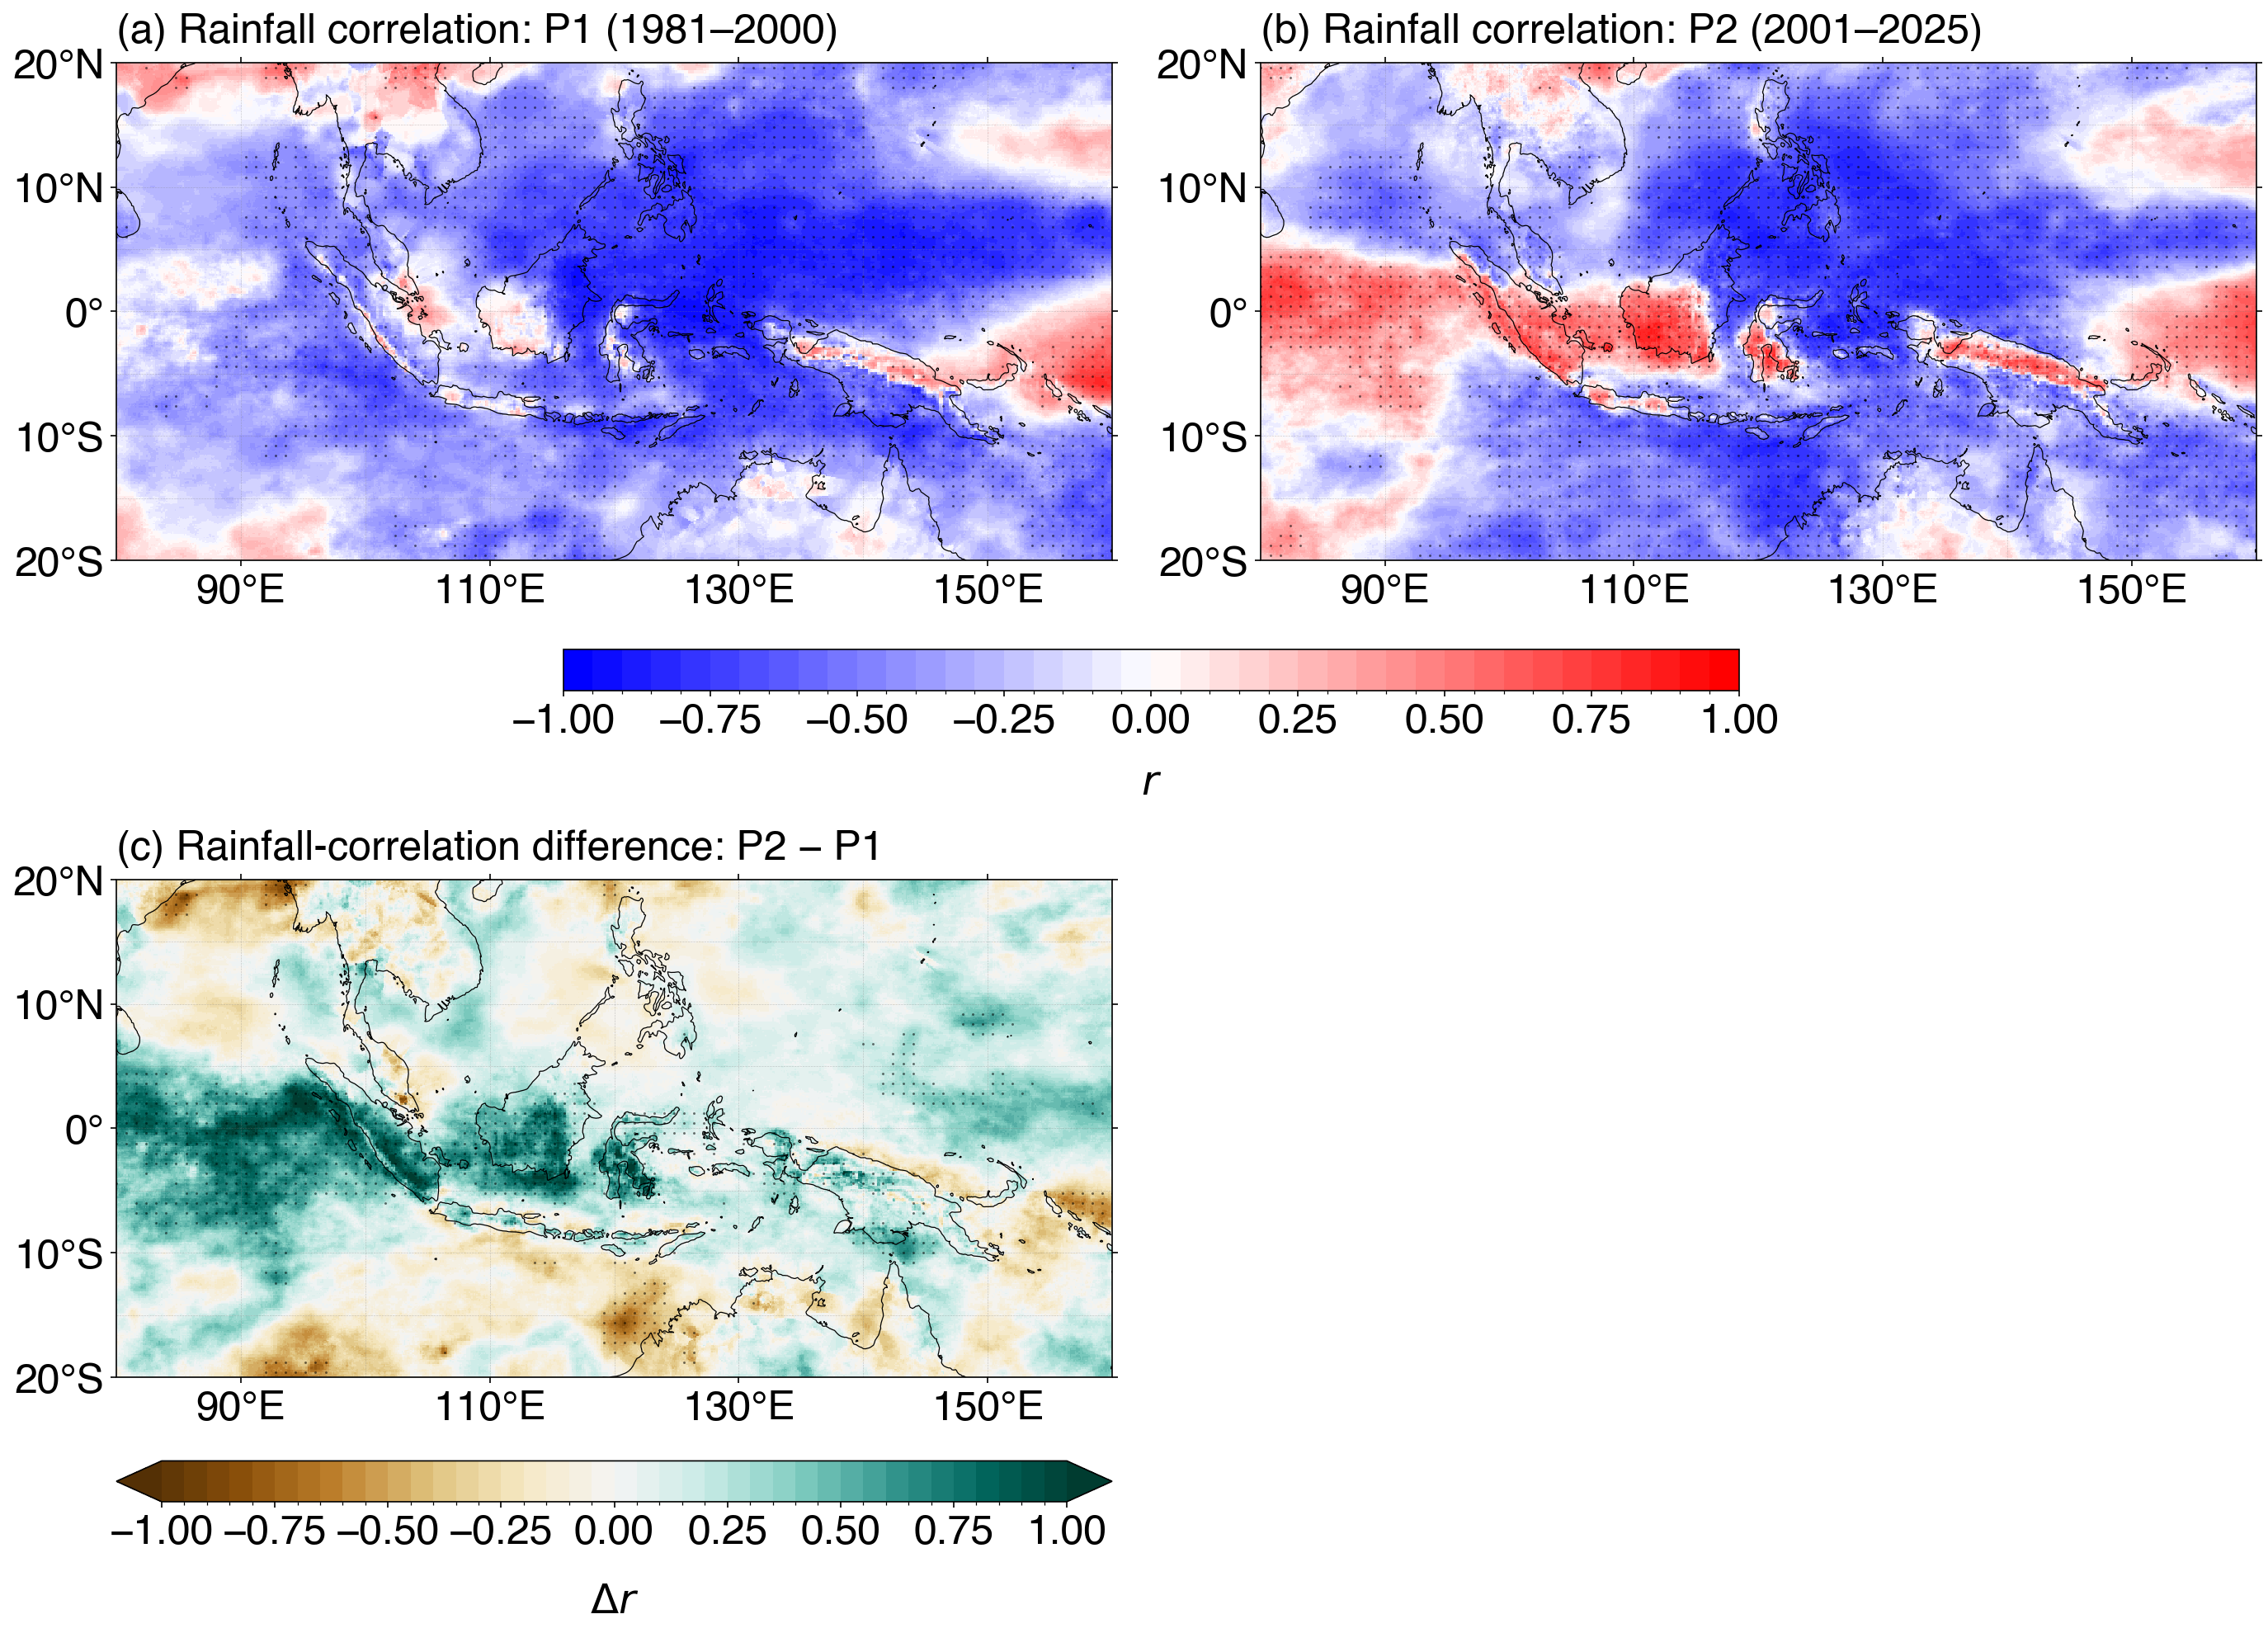

In [3]:
# ===== FIGURE LAYOUT CONTROLS =====
fig_width = 19
fig_height = 15
subplot_wspace = 0.35
subplot_hspace = 0.1

fig = plt.figure(figsize=(fig_width, fig_height))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=subplot_hspace, wspace=subplot_wspace)
ax1 = fig.add_subplot(gs[0, 0:2], projection=ccrs.PlateCarree(central_longitude=180))
ax2 = fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree(central_longitude=180))
ax3 = fig.add_subplot(gs[1, 0:2], projection=ccrs.PlateCarree(central_longitude=180))

map_panels = [
    (ax1, rain_corr_p1, rain_corr_p1_sig, '(a) Rainfall correlation: P1 (1981–2000)', 'bwr', 'neither'),
    (ax2, rain_corr_p2, rain_corr_p2_sig, '(b) Rainfall correlation: P2 (2001–2025)', 'bwr', 'neither'),
    (ax3, rain_corr_diff, rain_corr_diff_sig, '(c) Rainfall-correlation difference: P2 − P1', 'BrBG', 'both'),
]

top_img = None
diff_img = None
for ax, data, sig_mask, title, cmap, extend in map_panels:
    img = data.reset_coords(drop=True).plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, levels=corr_levels,
        extend=extend, add_colorbar=False, add_labels=False, infer_intervals=True,
    )
    if ax is ax3:
        diff_img = img
    else:
        top_img = img

    # Coarsening keeps the significance stippling legible at figure scale.
    sig_plot = (sig_mask.fillna(False).astype(np.int8)
                .coarsen(lat=8, lon=8, boundary='trim').max() > 0)
    yy, xx = np.where(sig_plot.values)
    if yy.size > 0:
        ax.scatter(sig_plot['lon'].values[xx], sig_plot['lat'].values[yy], s=8,
                   c='k', marker='.', linewidths=0, alpha=0.55,
                   transform=ccrs.PlateCarree(), zorder=4)

    ax.coastlines(resolution='50m', linewidth=0.6, color='black', zorder=3)
    ax.set_extent(mc_extent, crs=ccrs.PlateCarree())
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.4, linestyle='--')
    ax.set_xticks(mc_xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(mc_yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'}))
    ax.yaxis.set_major_formatter(LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'}))
    ax.tick_params(direction='out', top=True, right=True, labelsize=24)
    ax.set_title(title, loc='left', fontweight='bold', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.subplots_adjust(left=0.06, right=0.97, bottom=0.10, top=0.94)
fig.canvas.draw()
pos_p1, pos_p2, pos_diff = ax1.get_position(), ax2.get_position(), ax3.get_position()

# Shared P1/P2 colorbar placed between the map rows.
top_cax = fig.add_axes([0.25, pos_p1.y0 - 0.070, 0.50, 0.022])
top_cbar = fig.colorbar(top_img, cax=top_cax, orientation='horizontal', ticks=corr_ticks, extend='neither')
top_cbar.set_label(r'$\it{r}$', rotation=0, labelpad=14, fontsize=24)
top_cbar.ax.tick_params(labelsize=24)
top_cbar.ax.yaxis.set_label_position('right')

# Difference colorbar belongs directly beneath panel (c).
diff_cax = fig.add_axes([pos_diff.x0, pos_diff.y0 - 0.067, pos_diff.width, 0.022])
diff_cbar = fig.colorbar(diff_img, cax=diff_cax, orientation='horizontal', ticks=corr_ticks, extend='both')
diff_cbar.set_label(r'$\Delta r$', rotation=0, labelpad=18, fontsize=24)
diff_cbar.ax.tick_params(labelsize=24)
diff_cbar.ax.yaxis.set_label_position('right')

fig.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
print(f'Saved: {OUTPUT_PATH}')
plt.show()
rain_ds.close()


## Output

The finished figure is saved as `korelasi2001.png` in this folder.
